In [1]:
from tiffany_knn import kfold, normalize, kfold_classes, kfold_numbers
from sklearn import datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


%load_ext autoreload
%autoreload 2

In [2]:
parkinsons_df = pd.read_csv("../res/parkinsons.csv")
credit_df = pd.read_csv("../res/credit_approval.csv")
rice_df = pd.read_csv("../res/rice.csv")
digits = datasets.load_digits(return_X_y=True)
digits_dataset_X = digits[0]
digits_dataset_y = digits[1]
N = len(digits_dataset_X)
digits_df = pd.DataFrame(digits_dataset_X)
digits_df['label'] = digits_dataset_y

In [ ]:
parkinsons_df = normalize(parkinsons_df)
parkinsons_metrics_df = pd.DataFrame(columns=['k', 'acc', 'f1'])
print("Parkinsons")
for neighbors in range(1, 53, 2):
    metrics = kfold(parkinsons_df, 10, neighbors, "Diagnosis")
    parkinsons_metrics_df.loc[len(parkinsons_metrics_df)] = {'k': neighbors, 'acc': metrics[0], 'f1': metrics[1]}
    print("Finished k=", neighbors)

Parkinsons
Finished k= 1
Finished k= 3
Finished k= 5
Finished k= 7
Finished k= 9
Finished k= 11
Finished k= 13
Finished k= 15
Finished k= 17
Finished k= 19
Finished k= 21
Finished k= 23
Finished k= 25
Finished k= 27
Finished k= 29
Finished k= 31
Finished k= 33
Finished k= 35
Finished k= 37
Finished k= 39
Finished k= 41
Finished k= 43
Finished k= 45
Finished k= 47
Finished k= 49
Finished k= 51


In [23]:
parkinsons_metrics_df

,k,acc,f1
0,1,0.966667,0.978033
1,3,0.944444,0.963738
2,5,0.944444,0.964514
3,7,0.944444,0.965475
4,9,0.927778,0.954590
5,11,0.900000,0.937926
6,13,0.872222,0.922714
7,15,0.861111,0.915862
8,17,0.850000,0.910674
9,19,0.838889,0.903946


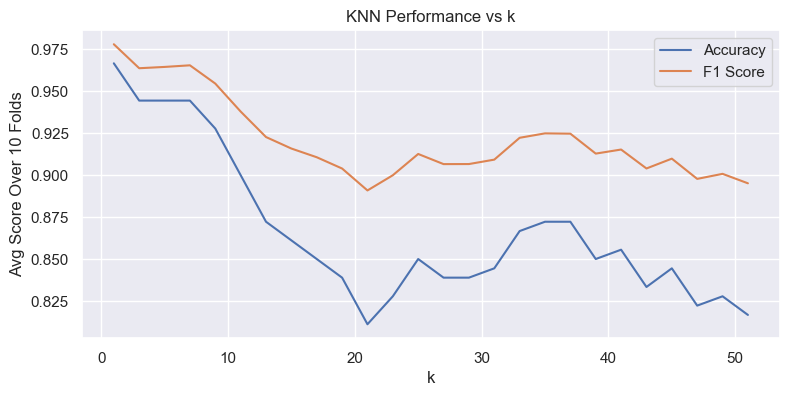

<Figure size 640x480 with 0 Axes>

In [49]:
sns.set_theme()
plt.figure(figsize=(9, 4))

sns.lineplot(data=parkinsons_metrics_df, x='k', y='acc', label='Accuracy')
sns.lineplot(data=parkinsons_metrics_df, x='k', y='f1', label='F1 Score')

plt.xlabel('k')
plt.ylabel('Avg Score Over 10 Folds')
plt.title('KNN Performance vs k')
plt.legend()

plt.show()
plt.savefig(f"../knn_figures/parkinsons_knn.png")

In [8]:
credit_metrics_df = pd.DataFrame(columns=['k', 'acc', 'f1'])
credit_df[credit_df.select_dtypes(include=['object', 'category']).columns] = \
    credit_df.select_dtypes(include=['object', 'category']).apply(lambda col: pd.factorize(col)[0])
credit_df = normalize(credit_df)

print("Credit")
for neighbors in range(1, 53, 2):
    metrics = kfold(credit_df, 10, neighbors, "label")
    credit_metrics_df.loc[len(credit_metrics_df)] = {'k': neighbors, 'acc': metrics[0], 'f1': metrics[1]}
    print(f"Finished k={neighbors}, acc={metrics[0]}, f1={metrics[1]}")

Credit
Finished k=1, acc=0.80625, f1=0.7801580446015562
Finished k=3, acc=0.859375, f1=0.8450932961281599
Finished k=5, acc=0.8640625, f1=0.8532194314754529
Finished k=7, acc=0.8734375, f1=0.8645957811979208
Finished k=9, acc=0.8625, f1=0.8549678125317746
Finished k=11, acc=0.865625, f1=0.8585355157645344
Finished k=13, acc=0.85625, f1=0.8488344811389409
Finished k=15, acc=0.8609375, f1=0.8543095298281773
Finished k=17, acc=0.8625, f1=0.8581923805375972
Finished k=19, acc=0.8640625, f1=0.8602471082068973
Finished k=21, acc=0.865625, f1=0.8608558580110955
Finished k=23, acc=0.8578125, f1=0.853120267154867
Finished k=25, acc=0.8640625, f1=0.8588738642024552
Finished k=27, acc=0.8671875, f1=0.8631061525809285
Finished k=29, acc=0.8578125, f1=0.8544018198736524
Finished k=31, acc=0.8609375, f1=0.8562632263595148
Finished k=33, acc=0.86875, f1=0.8655784185144997
Finished k=35, acc=0.8578125, f1=0.8524172467298319
Finished k=37, acc=0.8625, f1=0.8572524617534656
Finished k=39, acc=0.8640625,

In [10]:
credit_metrics_df

,k,acc,f1
0,1,0.806250,0.780158
1,3,0.859375,0.845093
2,5,0.864062,0.853219
3,7,0.873437,0.864596
4,9,0.862500,0.854968
5,11,0.865625,0.858536
6,13,0.856250,0.848834
7,15,0.860938,0.854310
8,17,0.862500,0.858192
9,19,0.864062,0.860247


In [12]:
credit_metrics_df['f1'].mean()

np.float64(0.8528917553080133)

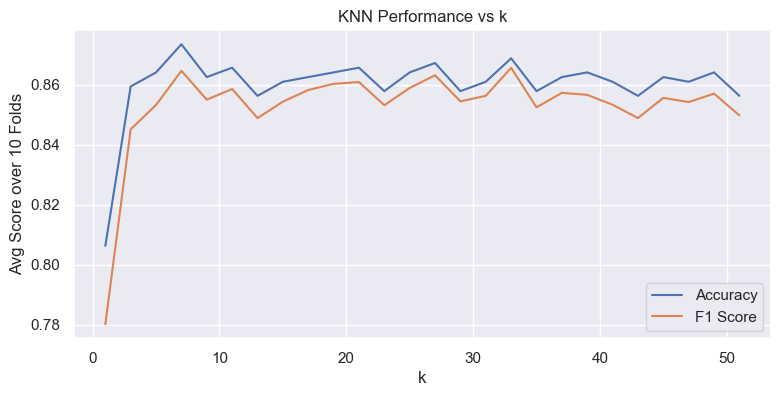

<Figure size 640x480 with 0 Axes>

In [9]:
sns.set_theme()
plt.figure(figsize=(9, 4))

sns.lineplot(data=credit_metrics_df, x='k', y='acc', label='Accuracy')
sns.lineplot(data=credit_metrics_df, x='k', y='f1', label='F1 Score')

plt.xlabel('k')
plt.ylabel('Avg Score over 10 Folds')
plt.title('KNN Performance vs k')
plt.legend()

plt.show()
plt.savefig(f"../knn_figures/credit_knn.png")

In [ ]:
num_cols = rice_df.select_dtypes(include='number').columns
rice_df[num_cols] = (rice_df[num_cols] - rice_df[num_cols].min()) / (rice_df[num_cols].max() - rice_df[num_cols].min())
rice_metrics_df = pd.DataFrame(columns=['k', 'acc', 'f1'])

print("Rice")
for neighbors in range(1, 53, 2):
    metrics = kfold_classes(rice_df, 10, neighbors, "Cammeo", "Osmancik", "label")
    rice_metrics_df.loc[len(rice_metrics_df)] = {'k': neighbors, 'acc': metrics[0], 'f1': metrics[1]}
    print(f"Finished k={neighbors}, acc={metrics[0]}, f1={metrics[1]}")
rice_metrics_df

Rice
Finished k= 1
Finished k= 3
Finished k= 5
Finished k= 7
Finished k= 9
Finished k= 11
Finished k= 13
Finished k= 15
Finished k= 17
Finished k= 19
Finished k= 21
Finished k= 23
Finished k= 25
Finished k= 27
Finished k= 29
Finished k= 31
Finished k= 33
Finished k= 35
Finished k= 37
Finished k= 39
Finished k= 41
Finished k= 43
Finished k= 45
Finished k= 47
Finished k= 49
Finished k= 51


,k,acc,f1
0,1,0.886614,0.867819
1,3,0.909974,0.894640
2,5,0.918898,0.904873
3,7,0.923885,0.910538
4,9,0.922047,0.908377
5,11,0.922835,0.909521
6,13,0.924409,0.911221
7,15,0.925984,0.913105
8,17,0.925984,0.912772
9,19,0.927034,0.914136


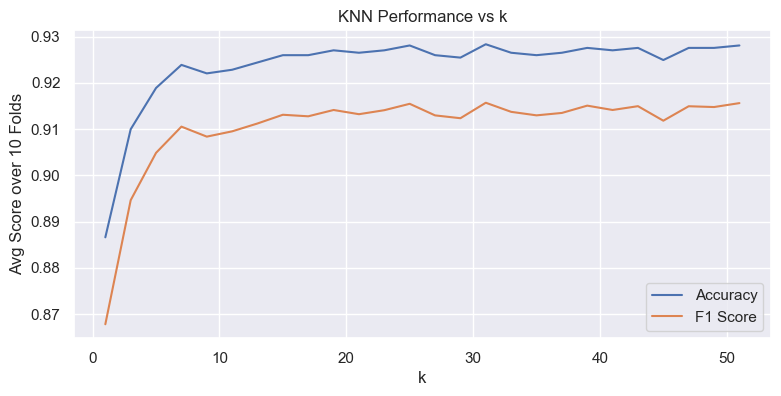

<Figure size 640x480 with 0 Axes>

In [68]:
sns.set_theme()
plt.figure(figsize=(9, 4))

sns.lineplot(data=rice_metrics_df, x='k', y='acc', label='Accuracy')
sns.lineplot(data=rice_metrics_df, x='k', y='f1', label='F1 Score')

plt.xlabel('k')
plt.ylabel('Avg Score over 10 Folds')
plt.title('KNN Performance vs k')
plt.legend()

plt.show()
plt.savefig(f"../knn_figures/rice_knn.png")

In [73]:
num_cols = digits_df.drop(columns=['label']).select_dtypes(include='number').columns
digits_df[num_cols] = (digits_df[num_cols] - digits_df[num_cols].min()) / (digits_df[num_cols].max() - digits_df[num_cols].min())
digits_metrics_df = pd.DataFrame(columns=['k', 'acc', 'f1'])

print("Digits")
for neighbors in range(1, 53, 2):
    metrics = kfold_numbers(digits_df, 10, neighbors, "label")
    digits_metrics_df.loc[len(digits_metrics_df)] = {'k': neighbors, 'acc': metrics[0], 'f1': metrics[1]}
    print("Finished k=", neighbors)
digits_metrics_df

Digits
Finished k= 1
Finished k= 3
Finished k= 5
Finished k= 7
Finished k= 9
Finished k= 11
Finished k= 13
Finished k= 15
Finished k= 17
Finished k= 19
Finished k= 21
Finished k= 23
Finished k= 25
Finished k= 27
Finished k= 29
Finished k= 31
Finished k= 33
Finished k= 35
Finished k= 37
Finished k= 39
Finished k= 41
Finished k= 43
Finished k= 45
Finished k= 47
Finished k= 49
Finished k= 51


,k,acc,f1
0,1,0.988571,0.989391
1,3,0.986857,0.987597
2,5,0.986286,0.987128
3,7,0.986286,0.987206
4,9,0.982857,0.984203
5,11,0.980571,0.982039
6,13,0.980000,0.980917
7,15,0.980571,0.982108
8,17,0.977143,0.978787
9,19,0.976000,0.977379


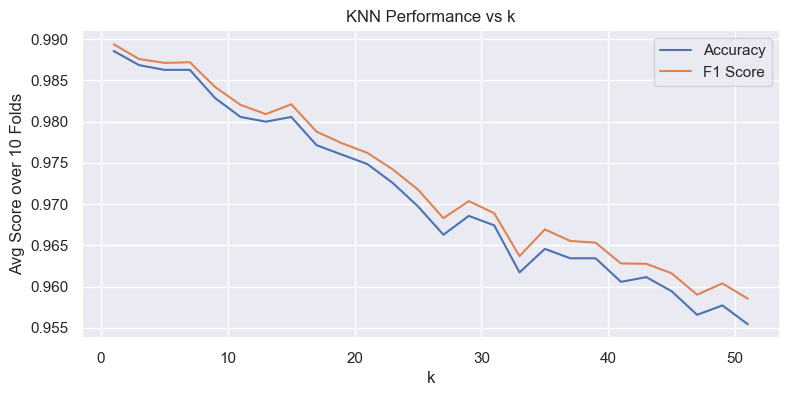

<Figure size 640x480 with 0 Axes>

In [74]:
sns.set_theme()
plt.figure(figsize=(9, 4))

sns.lineplot(data=digits_metrics_df, x='k', y='acc', label='Accuracy')
sns.lineplot(data=digits_metrics_df, x='k', y='f1', label='F1 Score')

plt.xlabel('k')
plt.ylabel('Avg Score over 10 Folds')
plt.title('KNN Performance vs k')
plt.legend()

plt.show()
plt.savefig(f"../knn_figures/digits_knn.png")